In [2]:
#import all the stuff
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib
#import xclim.indices
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob

In [69]:
cd /g/data/mn51/users/nb6195/project/vpd/VPD

/g/data/mn51/users/nb6195/project/vpd/VPD


In [20]:
def location_coords(location_dict, loc_name):
    lat_ind = round((location_dict[loc_name][0] + 44.5)/0.05)
    lon_ind = round((location_dict[loc_name][1] - 112)/0.05)
    return [lat_ind, lon_ind]

In [27]:
def location_data_sets(lat_ind, lon_ind, pathway, GCM, RCM):

    #import the files and create the datasets
    infiles12=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.2_vpd_days_gt_18.nc"
    thresh18_vpd_data_12 = xr.open_dataset(infiles12)['vpd']/20
    infiles15=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.5_vpd_days_gt_18.nc"
    thresh18_vpd_data_15 = xr.open_dataset(infiles15)['vpd']/20
    infiles20=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl2.0_vpd_days_gt_18.nc"
    thresh18_vpd_data_20 = xr.open_dataset(infiles20)['vpd']/20
    infiles30=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl3.0_vpd_days_gt_18.nc"
    thresh18_vpd_data_30 = xr.open_dataset(infiles30)['vpd']/20
    
    gwl12_monthly_vpd_count = thresh18_vpd_data_12.isel(lat = lat_ind, lon = lon_ind)
    gwl15_monthly_vpd_count = thresh18_vpd_data_15.isel(lat = lat_ind, lon = lon_ind)
    gwl20_monthly_vpd_count = thresh18_vpd_data_20.isel(lat = lat_ind, lon = lon_ind)
    gwl30_monthly_vpd_count = thresh18_vpd_data_30.isel(lat = lat_ind, lon = lon_ind)

    thresh18_vpd_data_12.close()
    thresh18_vpd_data_15.close()
    thresh18_vpd_data_20.close()
    thresh18_vpd_data_30.close()

    return gwl12_monthly_vpd_count, gwl15_monthly_vpd_count, gwl20_monthly_vpd_count, gwl30_monthly_vpd_count

In [75]:
#function to plot location based data for four GWLs, centred on the southern fire season
#input: location based data at four GWLs
#output: line plot with monthly data at all four GWLs
def summer_centre_gwl_lineplot(GCM, RCM, loc_name, gwl12_ds, gwl15_ds, gwl20_ds, gwl30_ds):
    # Month names for plotting
    months = ["July", "Aug", "Sept", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "June"]
    gwl12_shifted = [gwl12_ds[6], gwl12_ds[7], gwl12_ds[8], gwl12_ds[9], gwl12_ds[10], gwl12_ds[11], gwl12_ds[0], gwl12_ds[1], gwl12_ds[2], gwl12_ds[3], gwl12_ds[4], gwl12_ds[5]]
    gwl15_shifted = [gwl15_ds[6], gwl15_ds[7], gwl15_ds[8], gwl15_ds[9], gwl15_ds[10], gwl15_ds[11], gwl15_ds[0], gwl15_ds[1], gwl15_ds[2], gwl15_ds[3], gwl15_ds[4], gwl15_ds[5]]
    gwl20_shifted = [gwl20_ds[6], gwl20_ds[7], gwl20_ds[8], gwl20_ds[9], gwl20_ds[10], gwl20_ds[11], gwl20_ds[0], gwl20_ds[1], gwl20_ds[2], gwl20_ds[3], gwl20_ds[4], gwl20_ds[5]]
    gwl30_shifted = [gwl30_ds[6], gwl30_ds[7], gwl30_ds[8], gwl30_ds[9], gwl30_ds[10], gwl30_ds[11], gwl30_ds[0], gwl30_ds[1], gwl30_ds[2], gwl30_ds[3], gwl30_ds[4], gwl30_ds[5]]

    plt.plot(months, gwl12_shifted, label = "GWL1.2")
    plt.plot(months, gwl15_shifted, label = "GWL1.5")
    plt.plot(months, gwl20_shifted, label = "GWL2.0")
    plt.plot(months, gwl30_shifted, label = "GWL3.0")
    plt.plot(months, [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15], label = "15 days")
    plt.ylim(1,30)
    plt.legend()
    plt.xlabel('Month')
    plt.ylabel('Average number of days with VPD > 18')
    plt.title('Average number of days with VPD > 18 hPa at various GWLs\n%s %s\n%s' %(GCM, RCM, loc_name))
    outfile = 'location_images/' + loc_name + '_' + GCM + '_' + RCM + '.png'
    plt.savefig(outfile)
    plt.show()

In [ ]:
#function
#input: location, 
#output: ds with monthly values for all models for a given location
def get_all_model_data_location(loc_lat, loc_lon, agencies, ):
    #initialise 
    #num_models = 

In [76]:
#define dictionaries
BOM_models = {
    'ACCESS-ESM1-5' : 'r6i1p1f1',
    'NorESM2-MM' : 'r1i1p1f1',
    'ACCESS-CM2' : 'r4i1p1f1',
    'CESM2' : 'r11i1p1f1',
    'CMCC-ESM2' : 'r1i1p1f1',
    'EC-Earth3' : 'r1i1p1f1',
    'MPI-ESM1-2-HR' : 'r1i1p1f1'
    
}

CSIRO_models = {
    'ACCESS-ESM1-5' : 'r6i1p1f1',
    'NorESM2-MM' : 'r1i1p1f1',
    'ACCESS-CM2' : 'r4i1p1f1',
    'CESM2' : 'r11i1p1f1',
    'CMCC-ESM2' : 'r1i1p1f1',
    'EC-Earth3' : 'r1i1p1f1',
    'CNRM-ESM2-1' : 'r1i1p1f2'
}

model_dictionaries = {
    'BOM' : BOM_models,
    'CSIRO' : CSIRO_models
}

RCM_dict = {
    'BOM' : 'BARPA-R',
    'CSIRO' : 'CCAM-v2203-SN'
}

agencies = ['BOM', 'CSIRO']

location_dict = {
    'Adelaide' : [-34.95, 138.60],
    'Dandenongs' : [-37.8335, 145.3501],
    'Canberra' : [-35.2802, 149.1310],
    'Manjimup' : [-34.2432, 116.1453],
    'Cradle Mountain' : [-41.6800, 145.9400],
    'Kosciuszko' : [-36.4559, 148.2636],
    'Kuitpo' : [-35.2212, 138.6932]
}

In [77]:
pathway = 'ssp370'

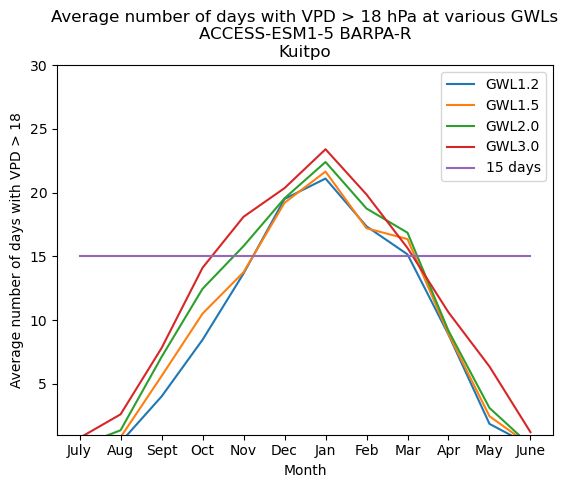

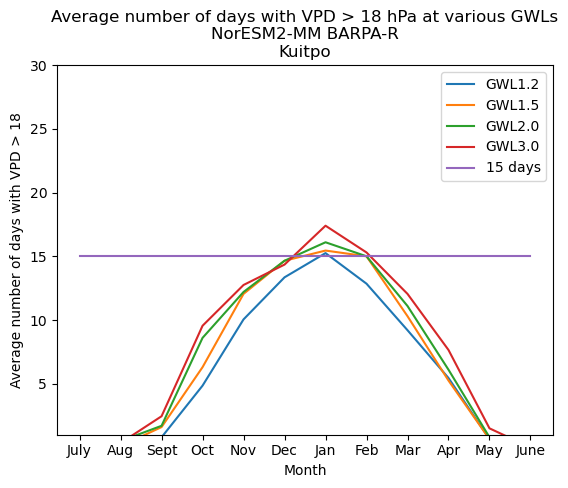

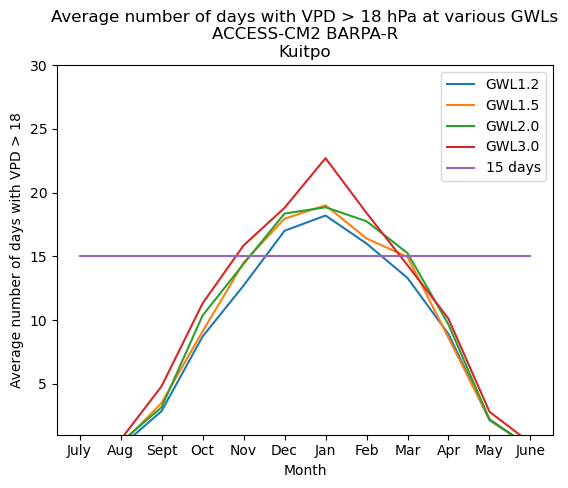

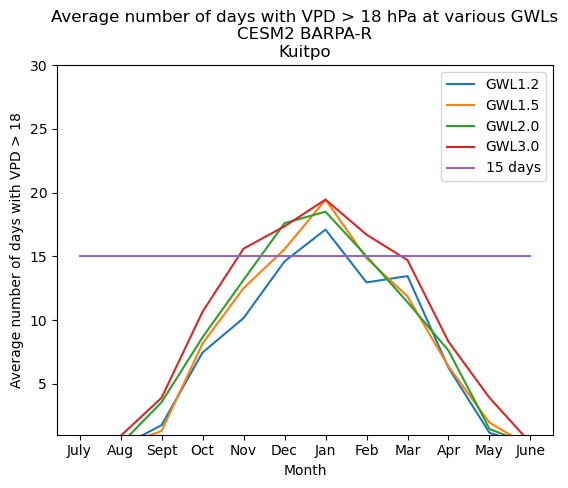

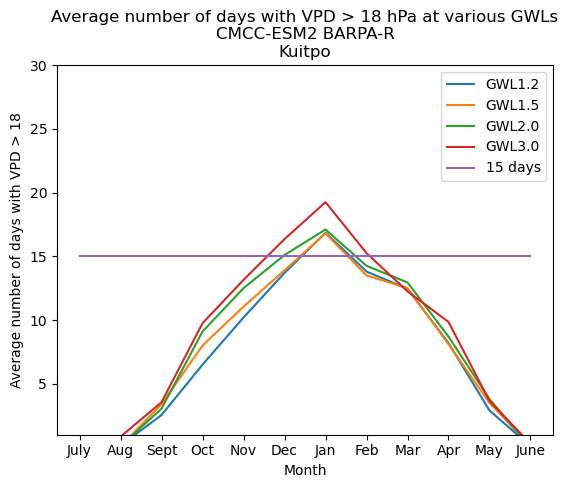

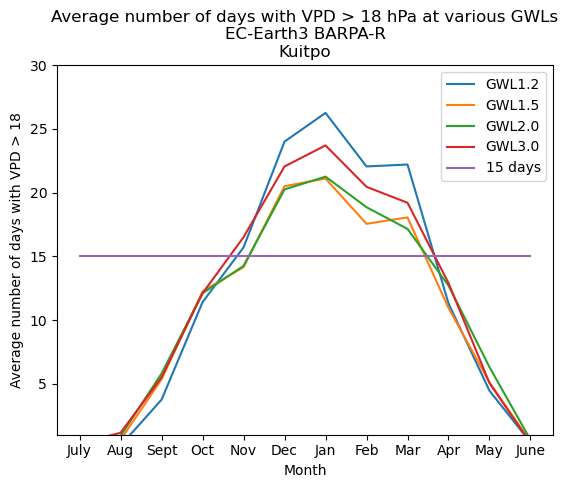

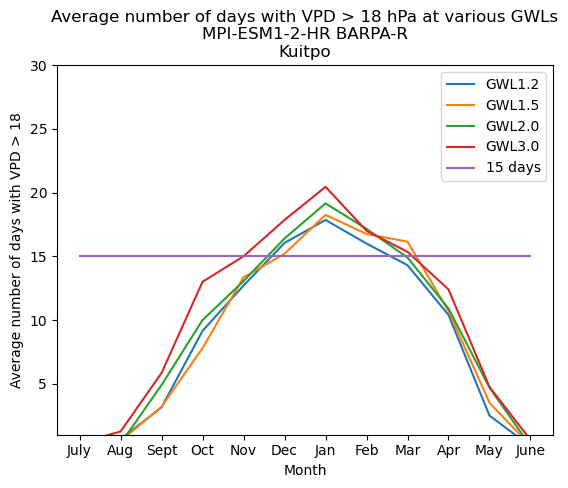

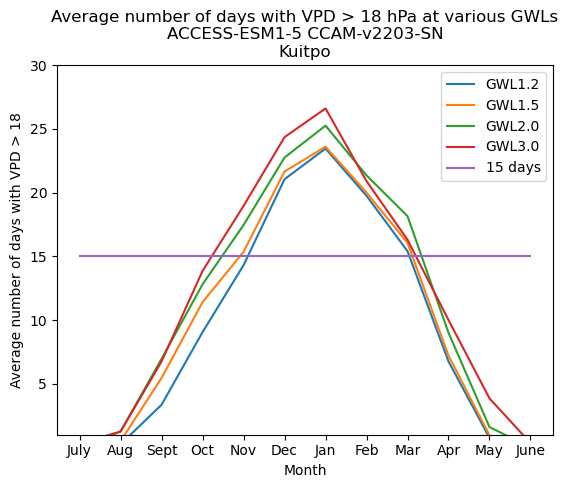

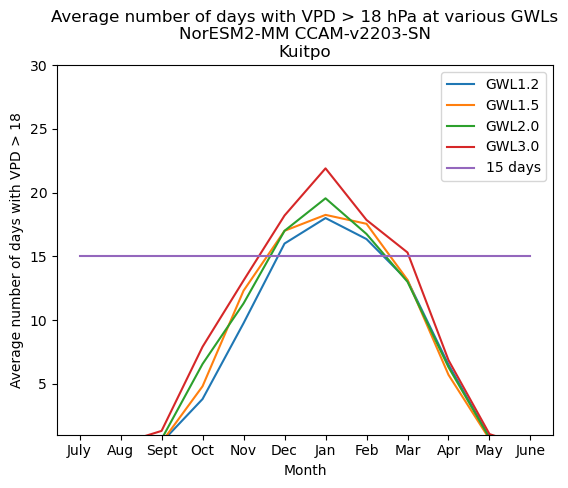

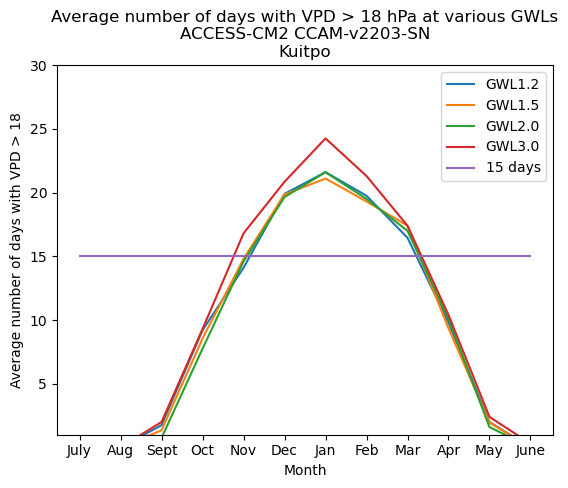

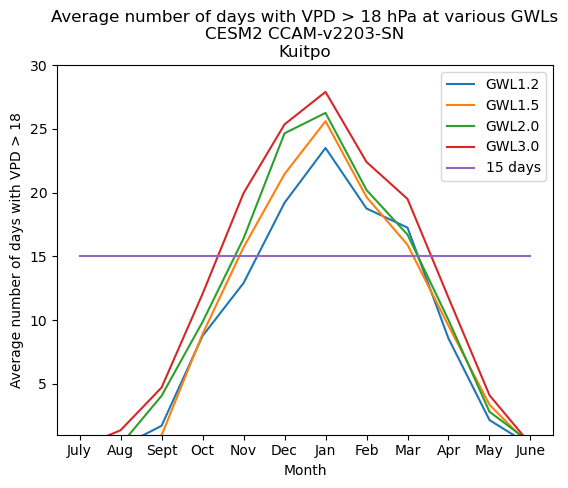

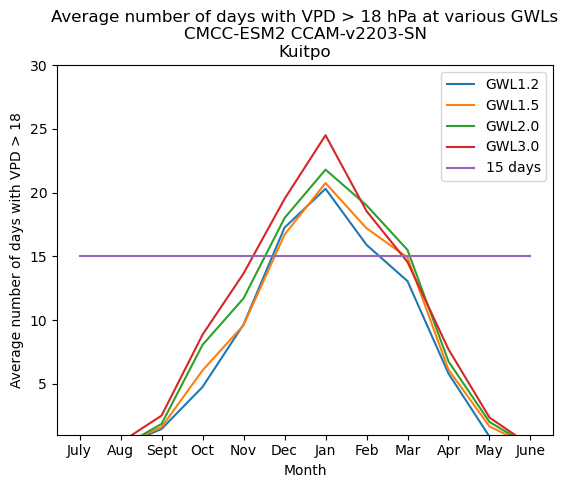

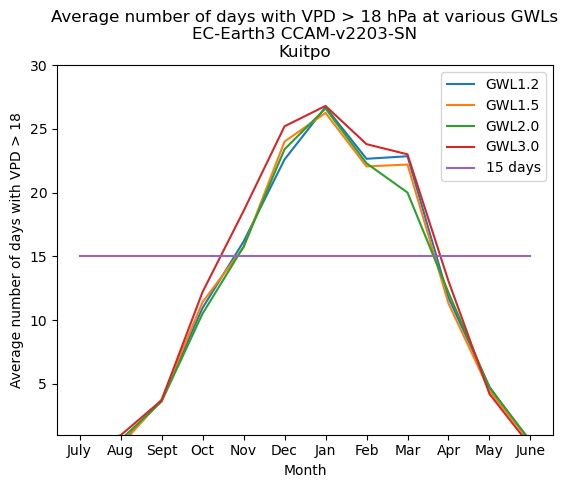

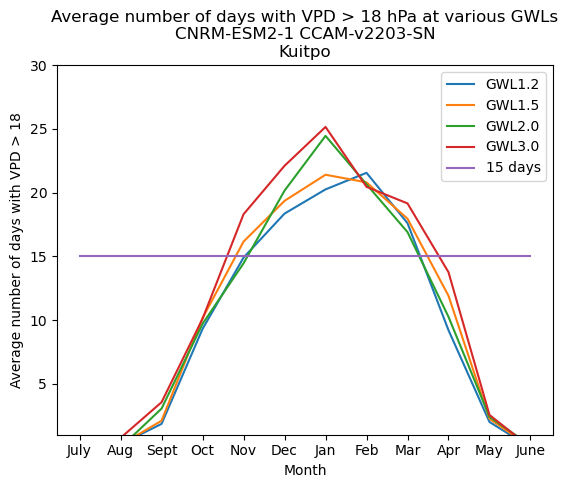

In [79]:
loc_name = 'Kuitpo'

for agency in agencies:
    RCM = RCM_dict[agency]
    agency_dictionary = model_dictionaries[agency]
    
    for GCM in agency_dictionary.keys():
        ensemble = agency_dictionary[GCM]
        #print(GCM)
        #print(ensemble)
        lat_ind, lon_ind = location_coords(location_dict, loc_name)
        gwl12_ds, gwl15_ds, gwl20_ds, gwl30_ds = location_data_sets(lat_ind, lon_ind, pathway, GCM, RCM)
        summer_centre_gwl_lineplot(GCM, RCM, loc_name, gwl12_ds, gwl15_ds, gwl20_ds, gwl30_ds)

In [104]:
#code to compare location based data across models
#create an empty list for each month for the location
jan_vpd_gwl12 = []
feb_vpd_gwl12 = []
mar_vpd_gwl12 = []
apr_vpd_gwl12 = []
may_vpd_gwl12 = []
jun_vpd_gwl12 = []
jul_vpd_gwl12 = []
aug_vpd_gwl12 = []
sep_vpd_gwl12 = []
oct_vpd_gwl12 = []
nov_vpd_gwl12 = []
dec_vpd_gwl12 = []

#extract the model data
for agency in agencies:
    RCM = RCM_dict[agency]
    agency_dictionary = model_dictionaries[agency]
    
    for GCM in agency_dictionary.keys():
        ensemble = agency_dictionary[GCM]
        
        infiles12=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.2_vpd_days_gt_18.nc"
        thresh18_vpd_data_12 = xr.open_dataset(infiles12)['vpd']/20
#        infiles15=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.5_vpd_days_gt_18.nc"
#        thresh18_vpd_data_15 = xr.open_dataset(infiles15)['vpd']/20
#        infiles20=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl2.0_vpd_days_gt_18.nc"
#        thresh18_vpd_data_20 = xr.open_dataset(infiles20)['vpd']/20
#        infiles30=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl3.0_vpd_days_gt_18.nc"
#        thresh18_vpd_data_30 = xr.open_dataset(infiles30)['vpd']/20
        
        gwl12_monthly_vpd_count = thresh18_vpd_data_12.isel(lat = lat_ind, lon = lon_ind)
#        gwl15_monthly_vpd_count = thresh18_vpd_data_15.isel(lat = lat_ind, lon = lon_ind)
#        gwl20_monthly_vpd_count = thresh18_vpd_data_20.isel(lat = lat_ind, lon = lon_ind)
#        gwl30_monthly_vpd_count = thresh18_vpd_data_30.isel(lat = lat_ind, lon = lon_ind)

        jan_vpd_gwl12.append(gwl12_monthly_vpd_count)
#        feb_vpd_gwl12.append
#        mar_vpd = []
#        apr_vpd = []
#        may_vpd = []
#        jun_vpd = []
#        jul_vpd = []
#        aug_vpd = []
#        sep_vpd = []
#        oct_vpd = []
#        nov_vpd = []
#        dec_vpd = []
    
        thresh18_vpd_data_12.close()
#        thresh18_vpd_data_15.close()
#        thresh18_vpd_data_20.close()
#        thresh18_vpd_data_30.close()




In [115]:
jan_vpd_gwl12

[<xarray.DataArray 'vpd' (month: 12)> Size: 96B
 array([21.1 , 17.35, 15.15,  8.85,  1.85,  0.15,  0.  ,  0.4 ,  4.  ,
         8.45, 13.65, 19.5 ])
 Coordinates:
     lat      float64 8B -35.2
     lon      float64 8B 138.7
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'vpd' (month: 12)> Size: 96B
 array([15.25, 12.85,  9.2 ,  5.45,  0.65,  0.  ,  0.  ,  0.05,  0.8 ,
         4.85, 10.05, 13.35])
 Coordinates:
     lat      float64 8B -35.2
     lon      float64 8B 138.7
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'vpd' (month: 12)> Size: 96B
 array([18.2 , 16.  , 13.3 ,  8.9 ,  2.15,  0.  ,  0.  ,  0.05,  2.85,
         8.7 , 12.7 , 17.  ])
 Coordinates:
     lat      float64 8B -35.2
     lon      float64 8B 138.7
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'vpd' (month: 12)> Size: 96B
 array([17.1 , 12.95, 13.45,  6.25,  1.15,  0.1 ,  0.  ,  0.05,  1.75,
         7.45, 10.15, 14.6

In [125]:
jan_vpd_gwl12[5][7]

<xarray.DataArray 'vpd' ()> Size: 8B
array(0.15)
Coordinates:
    lat      float64 8B -35.2
    lon      float64 8B 138.7
    month    int64 8B 8

In [ ]:
 array([26.25, 22.05, 22.2 , 11.3 ,  4.45,  0.4 ,  0.  ,  0.15,  3.75,
        11.4 , 15.7 , 24.  ])